# =========================================================
# Multi-Planar U-Net for Medical Image Segmentation (Colab)
# Author: Alan (FYP Medical Image Segmentation)
# =========================================================

In [22]:
!pip install torch torchvision matplotlib nibabel --quiet


In [23]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Synthetic 3D Dataset (Simulating CT Volumes)
# ---------------------------------------------------------

In [24]:
class SyntheticCTDataset(Dataset):
    """
    Generates synthetic 3D CT scans (random blobs).
    Each scan is (Depth, Height, Width).
    Segmentation task: detect blobs as foreground.
    """
    def __init__(self, num_samples=50, shape=(64, 64, 64), min_radius=5, max_radius=10, min_center=15, max_center=50):
        self.num_samples = num_samples
        self.shape = shape
        self.min_radius = min_radius
        self.max_radius = max_radius
        self.min_center = min_center
        self.max_center = max_center

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        vol = np.zeros(self.shape, dtype=np.float32)
        mask = np.zeros_like(vol)

        # Place a random spherical "tumor"
        cx, cy, cz = np.random.randint(self.min_center, self.max_center, size=3)
        r = np.random.randint(self.min_radius, self.max_radius)

        # Use vectorized NumPy operations to create the blob
        x_coords, y_coords, z_coords = np.meshgrid(np.arange(self.shape[0]), np.arange(self.shape[1]), np.arange(self.shape[2]), indexing='ij')
        distances = np.sqrt((x_coords - cx) ** 2 + (y_coords - cy) ** 2 + (z_coords - cz) ** 2)
        vol[distances < r] = 1.0
        mask[distances < r] = 1.0
        
        # Determine the slice where the center is located
        center_slice = cz
        
        vol = torch.tensor(vol).unsqueeze(0)  # (1, D, H, W)
        mask = torch.tensor(mask).unsqueeze(0)
        
        # Return the slice number as well for guaranteed visualization
        return vol, mask, center_slice

# ---------------------------------------------------------
# 2. Simple 2D U-Net (Reused from Notebook 1)
# ---------------------------------------------------------

In [25]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(64, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = DoubleConv(64, 32)
        self.final = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d1 = self.up1(b)
        d1 = torch.cat([d1, e2], dim=1)
        d1 = self.dec1(d1)
        d2 = self.up2(d1)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)
        return self.final(d2)

# ---------------------------------------------------------
# 3. Multi-Planar Fusion Model
# ---------------------------------------------------------

In [26]:
class MultiPlanarUNet(nn.Module):
    """
    Processes three orthogonal views (axial, coronal, sagittal)
    and fuses their predictions.
    """
    def __init__(self):
        super().__init__()
        self.unet_axial = UNet2D()
        self.unet_coronal = UNet2D()
        self.unet_sagittal = UNet2D()
        self.fusion = nn.Conv3d(3, 1, kernel_size=1)

    def forward(self, x):
        # x: (B, 1, D, H, W)
        B, C, D, H, W = x.shape

        # Axial (slices along depth)
        axial_preds = []
        for i in range(D):
            slice2d = x[:, :, i, :, :]  # (B, 1, H, W)
            p = self.unet_axial(slice2d)
            axial_preds.append(p.unsqueeze(2))  # Add depth dim
        axial_pred = torch.cat(axial_preds, dim=2)  # (B,1,D,H,W)

        # Coronal (slices along height)
        coronal_preds = []
        for i in range(H):
            slice2d = x[:, :, :, i, :]  # (B,1,D,W)
            p = self.unet_coronal(slice2d)
            coronal_preds.append(p.unsqueeze(3))
        coronal_pred = torch.cat(coronal_preds, dim=3)

        # Sagittal (slices along width)
        sagittal_preds = []
        for i in range(W):
            slice2d = x[:, :, :, :, i]  # (B,1,D,H)
            p = self.unet_sagittal(slice2d)
            sagittal_preds.append(p.unsqueeze(4))
        sagittal_pred = torch.cat(sagittal_preds, dim=4)

        # Fuse predictions
        preds = torch.cat([axial_pred, coronal_pred, sagittal_pred], dim=1)  # (B,3,D,H,W)
        out = torch.sigmoid(self.fusion(preds))
        return out

# ---------------------------------------------------------
# 4. Training Loop (Simplified)
# ---------------------------------------------------------

In [27]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for vol, mask, _ in loader:  # Unpack the new third return value
        vol, mask = vol.to(device), mask.to(device)
        optimizer.zero_grad()
        preds = model(vol)
        loss = criterion(preds, mask)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)



# ---------------------------------------------------------
# 5. Run Training
# ---------------------------------------------------------

Epoch 1, Loss: 9.0846
Epoch 2, Loss: 8.9011
Epoch 3, Loss: 8.4834
Epoch 4, Loss: 5.5211
Epoch 5, Loss: 1.0897
Epoch 6, Loss: 0.7143
Epoch 7, Loss: 0.4977
Epoch 8, Loss: 0.4348
Epoch 9, Loss: 0.3134
Epoch 10, Loss: 0.2376
Epoch 11, Loss: 0.1458
Epoch 12, Loss: 0.0703
Epoch 13, Loss: 0.0429
Epoch 14, Loss: 0.0367
Epoch 15, Loss: 0.0283
Epoch 16, Loss: 0.0263
Epoch 17, Loss: 0.0178
Epoch 18, Loss: 0.0132
Epoch 19, Loss: 0.0112
Epoch 20, Loss: 0.0092

Displaying slice: 12


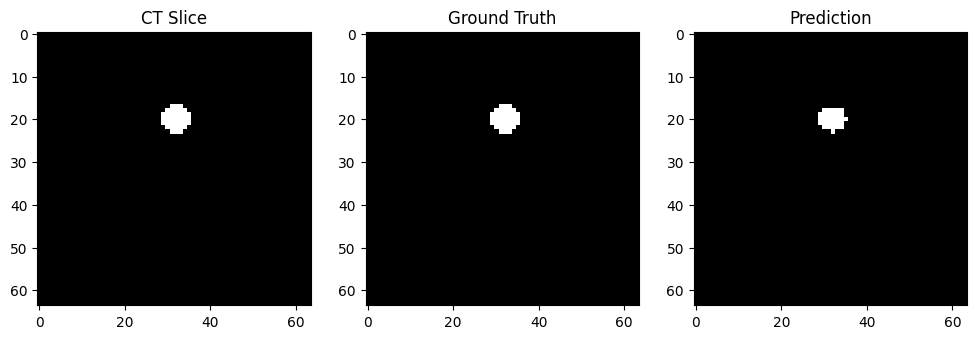

In [28]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dataset = SyntheticCTDataset(num_samples=50)
    loader = DataLoader(dataset, batch_size=4, shuffle=True)

    model = MultiPlanarUNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4) # Reduced learning rate
    
    # Updated Loss Function with a weight
    weight = torch.tensor([10.0]).to(device) 
    criterion = nn.BCELoss(weight=weight)

    for epoch in range(20):
        loss = train(model, loader, optimizer, criterion, device)
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

    # --- THIS IS THE NEW, SMARTER VISUALIZATION CODE ---
    # Show one slice prediction
    vol, mask, _ = dataset[0]  # Unpack all three values

    # Find a slice that actually contains the "tumor"
    z_coords, _, _ = np.where(mask.squeeze() > 0)
    slice_idx = z_coords[0] if len(z_coords) > 0 else 32 # Pick a slice with a tumor, or default to 32

    # Run inference
    vol_tensor = vol.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(vol_tensor).cpu().squeeze().numpy()

    # Display the interesting slice
    print(f"\nDisplaying slice: {slice_idx}")
    plt.figure(figsize=(12, 4))
    plt.subplot(1,3,1)
    plt.imshow(vol.cpu().squeeze()[slice_idx,:,:], cmap="gray")
    plt.title("CT Slice")
    plt.subplot(1,3,2)
    plt.imshow(mask.squeeze()[slice_idx,:,:], cmap="gray")
    plt.title("Ground Truth")
    plt.subplot(1,3,3)
    plt.imshow(pred[slice_idx,:,:] > 0.5, cmap="gray")
    plt.title("Prediction")
    plt.show()

if __name__ == "__main__":
    main()